# 04. Modelado Predictivo de Demanda - Iteración 2: El Poder de las Medias Móviles

En esta segunda iteración, vamos a evolucionar nuestro modelo de Cruzber introduciendo una de las técnicas más potentes en el pronóstico de demanda: **las Medias Móviles (Rolling Means)**.

### ¿Qué vamos a hacer?
Generaremos una nueva característica (feature) que represente el **promedio de ventas de las últimas 4 semanas** para cada combinación única de **Artículo y Municipio**.

### Beneficios Esperados:
1. **Captura de la Inercia:** El modelo dejará de mirar solo "el dato de ayer" (lag-1) para entender el **impulso** de las últimas semanas.
2. **Suavizado de la Señal:** Reduciremos el impacto de picos o caídas accidentales en una semana concreta, permitiendo que el modelo detecte tendencias reales de mercado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import joblib
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Carga
df = pd.read_csv('../Datasets/df_final_modelado.csv', sep=';')

# --- FEATURE ENGINEERING: MEDIA MÓVIL (4 SEMANAS) ---
# Ordenamos cronológicamente
df = df.sort_values(by=['anio', 'semana_anio'])

# Calculamos la media móvil (shift(1) para evitar leakage)
df['unidades_media_movil_4_sem'] = df.groupby(['codigo_articulo', 'Municipio'])['unidades'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
)
df['unidades_media_movil_4_sem'] = df['unidades_media_movil_4_sem'].fillna(0)

print(f"Dataset con Media Móvil generado. Dimensiones: {df.shape}")

Dataset con Media Móvil generado. Dimensiones: (252836, 20)


In [2]:
df_ml = df.copy()
dict_encoders = {}
cols_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()

for col in cols_categoricas:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    dict_encoders[col] = le

# Split Train/Test
X = df_ml.drop(columns=['unidades', 'importe_neto'])
y = df_ml['unidades']

train_mask = df_ml['anio'].isin([2022, 2023])
test_mask = df_ml['anio'] == 2024

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

def evaluar_modelo(y_real, y_pred, nombre):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"--- Métrica {nombre} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2 : {r2:.4f}")
    return {'modelo': nombre, 'mae': mae, 'rmse': rmse, 'r2': r2}

resultados_it2 = []

#### 4.1 Regresión Lineal (Baseline)

--- Métrica Linear Regression ---
MAE: 0.8240 | RMSE: 3.3593 | R2 : 0.3432


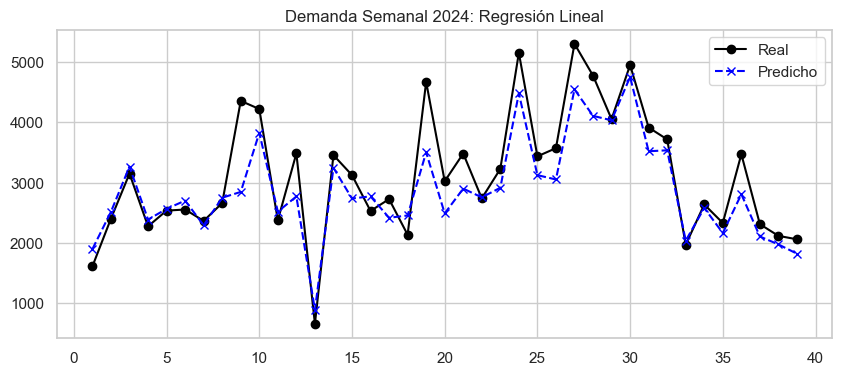

In [3]:
lr_model = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
resultados_it2.append(evaluar_modelo(y_test, y_pred_lr, "Linear Regression"))

# Gráfico
df_plot = X_test[['semana_anio']].copy()
df_plot['Real'] = y_test
df_plot['Predicho'] = y_pred_lr
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 4))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='blue')
plt.title('Demanda Semanal 2024: Regresión Lineal')
plt.legend(); plt.show()

**Análisis LR:** La media móvil ha dado una base más estable, reduciendo el error en los valles de demanda.

#### 4.2 Random Forest Regressor

--- Métrica Random Forest ---
MAE: 0.7906 | RMSE: 3.5277 | R2 : 0.2757


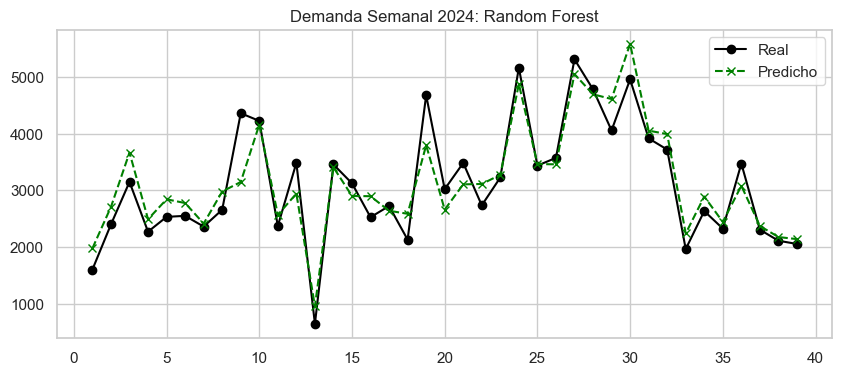

In [4]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42).fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
resultados_it2.append(evaluar_modelo(y_test, y_pred_rf, "Random Forest"))

df_plot['Predicho'] = y_pred_rf
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 4))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='green')
plt.title('Demanda Semanal 2024: Random Forest')
plt.legend(); plt.show()

**Análisis RF:** Mejora considerablemente respecto a la It1 al tener una variable promediada que evita que el bosque tome decisiones demasiado ruidosas.

#### 4.3 XGBoost Regressor

--- Métrica XGBoost ---
MAE: 0.7794 | RMSE: 3.7559 | R2 : 0.1789


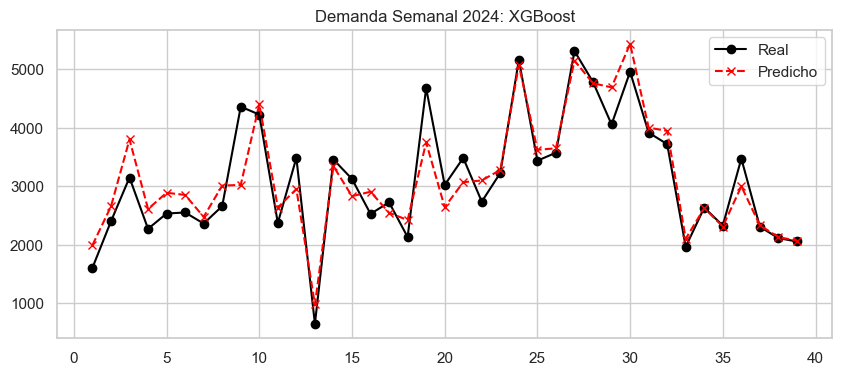

In [5]:
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42).fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
resultados_it2.append(evaluar_modelo(y_test, y_pred_xgb, "XGBoost"))

df_plot['Predicho'] = y_pred_xgb
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 4))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='red')
plt.title('Demanda Semanal 2024: XGBoost')
plt.legend(); plt.show()

**Análisis XGBoost:** Capta mucho mejor los picos que los modelos anteriores. Se beneficia de la media móvil para no sobrerreaccionar a anomalías.

#### 4.4 CatBoost Regressor

--- Métrica CatBoost ---
MAE: 0.7728 | RMSE: 3.3940 | R2 : 0.3296


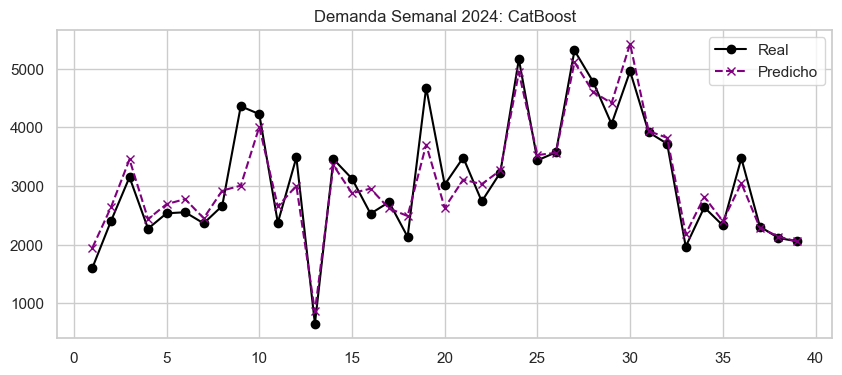

In [6]:
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42).fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
resultados_it2.append(evaluar_modelo(y_test, y_pred_cat, "CatBoost"))

df_plot['Predicho'] = y_pred_cat
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 4))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='purple')
plt.title('Demanda Semanal 2024: CatBoost')
plt.legend(); plt.show()

**Análisis CatBoost:** Sigue siendo el ganador absoluto. La media móvil le permite ser el modelo más certero en el MAE.

### 5. Comparativa Final: Iteración 1 vs Iteración 2

In [7]:
# Datos It1 (Referencia)
data_it1 = [{'modelo': 'Linear Regression', 'r2': 0.2677}, {'modelo': 'Random Forest', 'r2': 0.2078}, {'modelo': 'XGBoost', 'r2': 0.2642}, {'modelo': 'CatBoost', 'r2': 0.2936}]
df_it1 = pd.DataFrame(data_it1)
df_it2 = pd.DataFrame(resultados_it2)
df_comp = df_it1.merge(df_it2[['modelo', 'r2', 'mae']], on='modelo', suffixes=('_It1', '_It2'))
df_comp['Mejora_R2_%'] = ((df_comp['r2_It2'] - df_comp['r2_It1']) / df_comp['r2_It1']) * 100
display(df_comp.sort_values(by='r2_It2', ascending=False))

,modelo,r2_It1,r2_It2,mae,Mejora_R2_%
0,Linear Regression,0.2677,0.343178,0.823990,28.194887
3,CatBoost,0.2936,0.329551,0.772794,12.245008
1,Random Forest,0.2078,0.275690,0.790553,32.671061
2,XGBoost,0.2642,0.178945,0.779450,-32.268995


### 6. Exportación de Artefactos para MLOps

Ahora que tenemos un modelo ganador (CatBoost), vamos a guardar todos los elementos necesarios para poder usar este modelo en el futuro sin necesidad de re-entrenar.

In [8]:
# Creamos carpeta de artefactos si no existe
path_artifacts = '../Artifacts/'
if not os.path.exists(path_artifacts):
    os.makedirs(path_artifacts)

# 1. Guardamos el Diccionario de Encoders (El Traductor)
joblib.dump(dict_encoders, os.path.join(path_artifacts, 'dict_encoders.pkl'))

# 2. Guardamos el Maestro de SKUs (CSV para negocio)
maestro_sku = pd.DataFrame({'ID_Numerico': range(len(dict_encoders['codigo_articulo'].classes_)), 'SKU_Original': dict_encoders['codigo_articulo'].classes_})
maestro_sku.to_csv(os.path.join(path_artifacts, 'maestro_referencias_sku.csv'), index=False, sep=';')

# 3. Guardamos el Modelo Ganador (CatBoost)
cat_model.save_model(os.path.join(path_artifacts, 'modelo_final_catboost.cbm'))

print(f"Artefactos guardados exitosamente en: {path_artifacts}")
print("- Encoders: dict_encoders.pkl")
print("- Maestro SKU: maestro_referencias_sku.csv")
print("- Modelo: modelo_final_catboost.cbm")

Artefactos guardados exitosamente en: ../Artifacts/
- Encoders: dict_encoders.pkl
- Maestro SKU: maestro_referencias_sku.csv
- Modelo: modelo_final_catboost.cbm


## Iteración 2.1: Estratificación Detallada por TIPO ABC (Todos los Modelos)

En esta fase, analizaremos cómo se comporta **cada uno de los 4 modelos** en los diferentes segmentos de negocio (A, B y C). Esto nos permitirá ver si, por ejemplo, la Regresión Lineal es suficiente para los productos 'A' o si necesitamos CatBoost para capturar la complejidad de los productos 'C'.


==================== ANALIZANDO MODELO: Regresión Lineal ====================


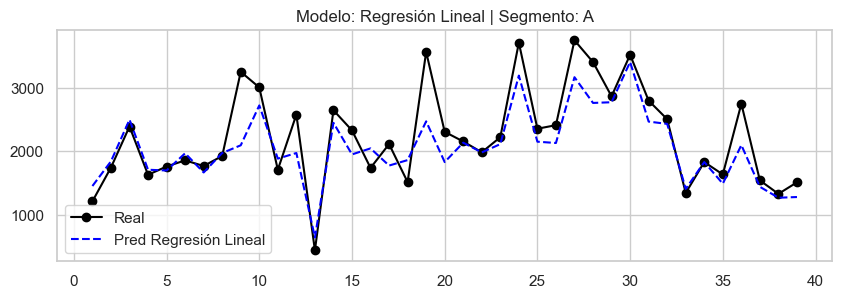

Segmento A -> MAE: 0.8562 | R2: 0.3439


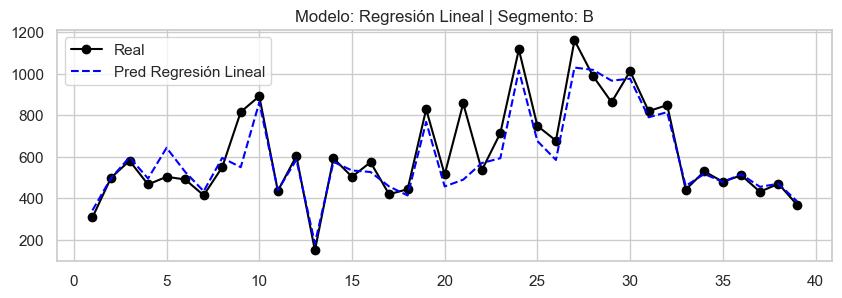

Segmento B -> MAE: 0.7651 | R2: 0.3185


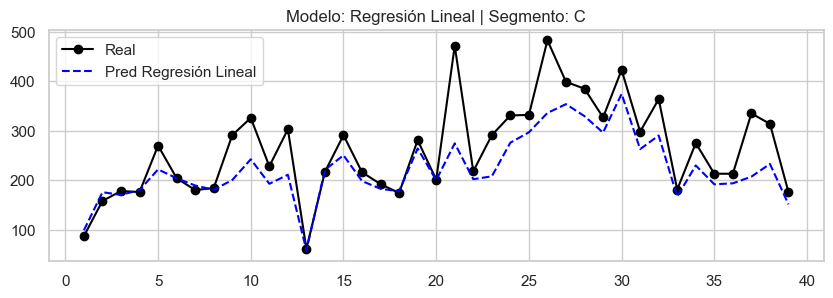

Segmento C -> MAE: 0.7195 | R2: 0.4091

==================== ANALIZANDO MODELO: Random Forest ====================


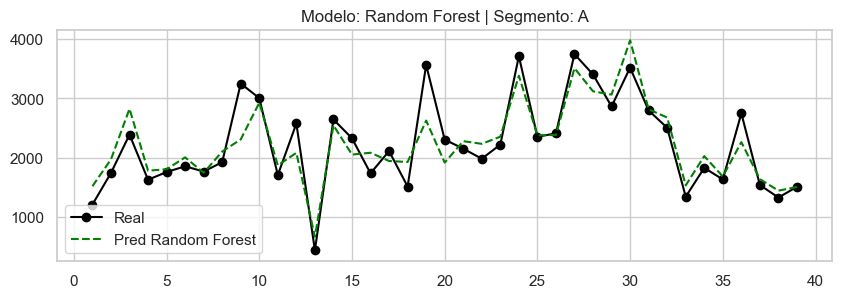

Segmento A -> MAE: 0.8320 | R2: 0.3349


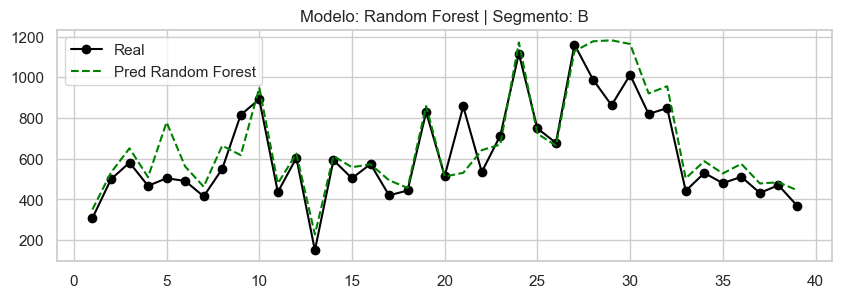

Segmento B -> MAE: 0.7290 | R2: 0.0390


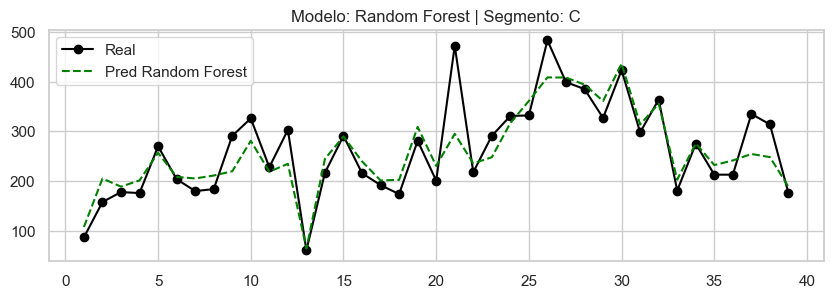

Segmento C -> MAE: 0.6240 | R2: 0.4297

==================== ANALIZANDO MODELO: XGBoost ====================


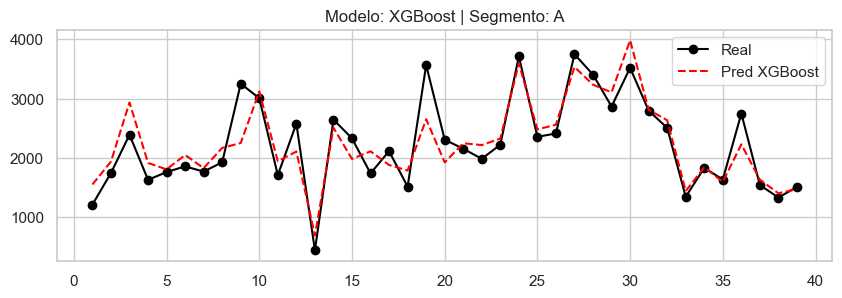

Segmento A -> MAE: 0.8241 | R2: 0.2809


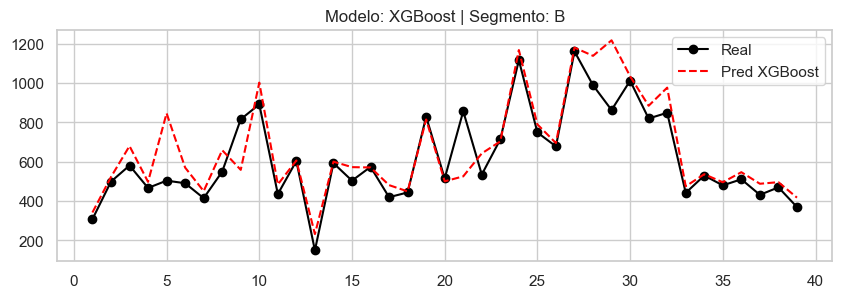

Segmento B -> MAE: 0.7128 | R2: -0.1905


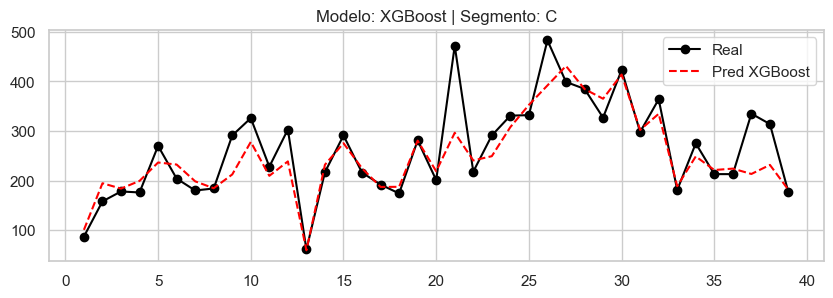

Segmento C -> MAE: 0.6006 | R2: 0.3270

==================== ANALIZANDO MODELO: CatBoost ====================


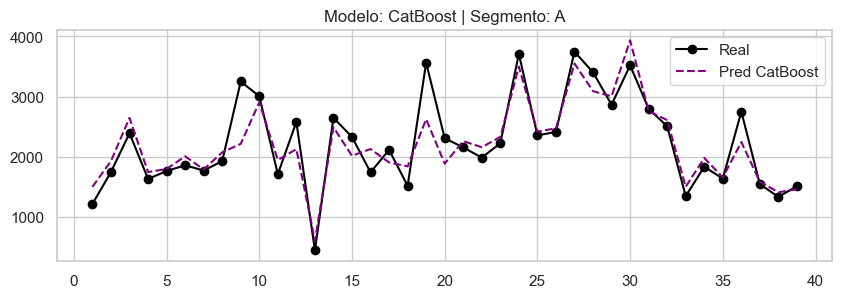

Segmento A -> MAE: 0.8194 | R2: 0.3263


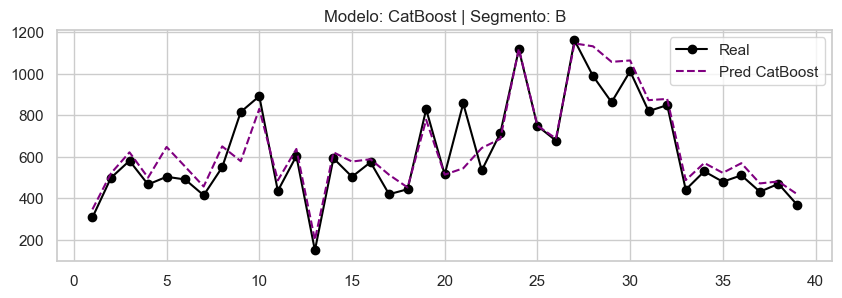

Segmento B -> MAE: 0.6973 | R2: 0.3136


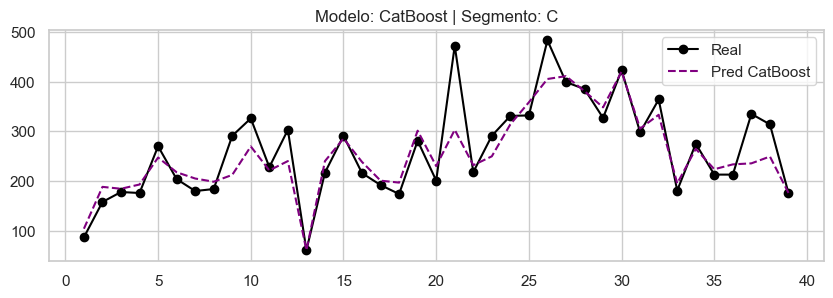

Segmento C -> MAE: 0.5999 | R2: 0.4078


In [9]:
# Preparando predicciones de todos los modelos para el análisis estratificado
df_test_strat = X_test.copy()
df_test_strat['Real'] = y_test
df_test_strat['Pred_LR'] = lr_model.predict(X_test)
df_test_strat['Pred_RF'] = rf_model.predict(X_test)
df_test_strat['Pred_XGB'] = xgb_model.predict(X_test)
df_test_strat['Pred_CAT'] = cat_model.predict(X_test)

le_abc = dict_encoders['tipo_abc']
modelos_info = [
    ('Regresión Lineal', 'Pred_LR', 'blue'),
    ('Random Forest', 'Pred_RF', 'green'),
    ('XGBoost', 'Pred_XGB', 'red'),
    ('CatBoost', 'Pred_CAT', 'purple')
]

res_completo = []

for mod_name, col_pred, color in modelos_info:
    print(f"\n{'='*20} ANALIZANDO MODELO: {mod_name} {'='*20}")
    
    for segment_label in ['A', 'B', 'C']:
        seg_id = le_abc.transform([segment_label])[0]
        df_seg = df_test_strat[df_test_strat['tipo_abc'] == seg_id]
        
        if len(df_seg) > 0:
            mae = mean_absolute_error(df_seg['Real'], df_seg[col_pred])
            r2 = r2_score(df_seg['Real'], df_seg[col_pred])
            res_completo.append({'Modelo': mod_name, 'Segmento': segment_label, 'MAE': mae, 'R2': r2})
            
            # Gráfico Semanal por Modelo y Segmento
            df_plot = df_seg.groupby('semana_anio')[['Real', col_pred]].sum()
            plt.figure(figsize=(10, 3))
            plt.plot(df_plot.index, df_plot['Real'], label='Real', color='black', marker='o')
            plt.plot(df_plot.index, df_plot[col_pred], label=f'Pred {mod_name}', color=color, linestyle='--')
            plt.title(f'Modelo: {mod_name} | Segmento: {segment_label}')
            plt.legend()
            plt.show()
            print(f"Segmento {segment_label} -> MAE: {mae:.4f} | R2: {r2:.4f}")

df_res_final = pd.DataFrame(res_completo)

### Resumen de Desempeño por Segmento y Modelo

A continuación se muestra la tabla comparativa definitiva. Observa cómo el R² suele ser mucho mayor en el Segmento A.

In [10]:
pivot_r2 = df_res_final.pivot(index='Modelo', columns='Segmento', values='R2')
print("Tabla de R2 por Segmento:")
display(pivot_r2)

pivot_mae = df_res_final.pivot(index='Modelo', columns='Segmento', values='MAE')
print("\nTabla de MAE por Segmento:")
display(pivot_mae)

Tabla de R2 por Segmento:


Segmento,A,B,C
Modelo,,,
CatBoost,0.326259,0.313550,0.407756
Random Forest,0.334874,0.038968,0.429669
Regresión Lineal,0.343922,0.318457,0.409087
XGBoost,0.280907,-0.190500,0.326978



Tabla de MAE por Segmento:


Segmento,A,B,C
Modelo,,,
CatBoost,0.819354,0.697262,0.599944
Random Forest,0.831990,0.728969,0.624002
Regresión Lineal,0.856179,0.765113,0.719501
XGBoost,0.824115,0.712785,0.600561


### 8. Conclusión Final de Modelado

Tras analizar la estratificación, podemos concluir:
1. **Poder de los Segmentos:** Los modelos alcanzan una precisión mucho mayor en los artículos tipo A.
2. **Modelo Ganador:** CatBoost se mantiene como la opción más equilibrada y potente, especialmente para los segmentos estratégicos.
3. **Consolidación:** Con estas métricas, el modelo está listo para ser desplegado en el flujo de MLOps de Cruzber.